# Power Based Channel Attacks 

Hello and welcome to our course about Side Channel Attacks using the teem emulator. While we will delve into multiple different attacks, we will begin by explaining the power model of our emulator and show you the basic statistical properties that are gonna be exploited by these attacks. 

## Setup 

First lets begin by making sure that the required depdendencies for running  the emulator as well as this notebook are installed. To do this please execute the codeblock below.

In [1]:
%matplotlib widget 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
#from benedict import benedict 
import prompt_toolkit
from src.power import CPAAttack

If you got an error when running the code cell above, please make sure to install the required dependencies into your python kernel. 

Now lets continue. The folder of this course contains a directory called traces, with a file called "example-traces.npy". This file contains 256 different sample traces from an AES encryption algorithm, more specifically the SubBytes stage of the algorithm. In power based side channel attacks on the AES algorithm this is the most common point of attack. The traces also only include the measurements of the cpu cycles which executed the following operation

```python
data[0] = sbox[clear_text[0] ^ key[0]]
```

Furthermore the recording contains only traces from the very first round of the AES run, because that is all that is required to break AES.
Next we will load the data and present you with two graphics which will demonstrate the differences we will abuse in our attack.

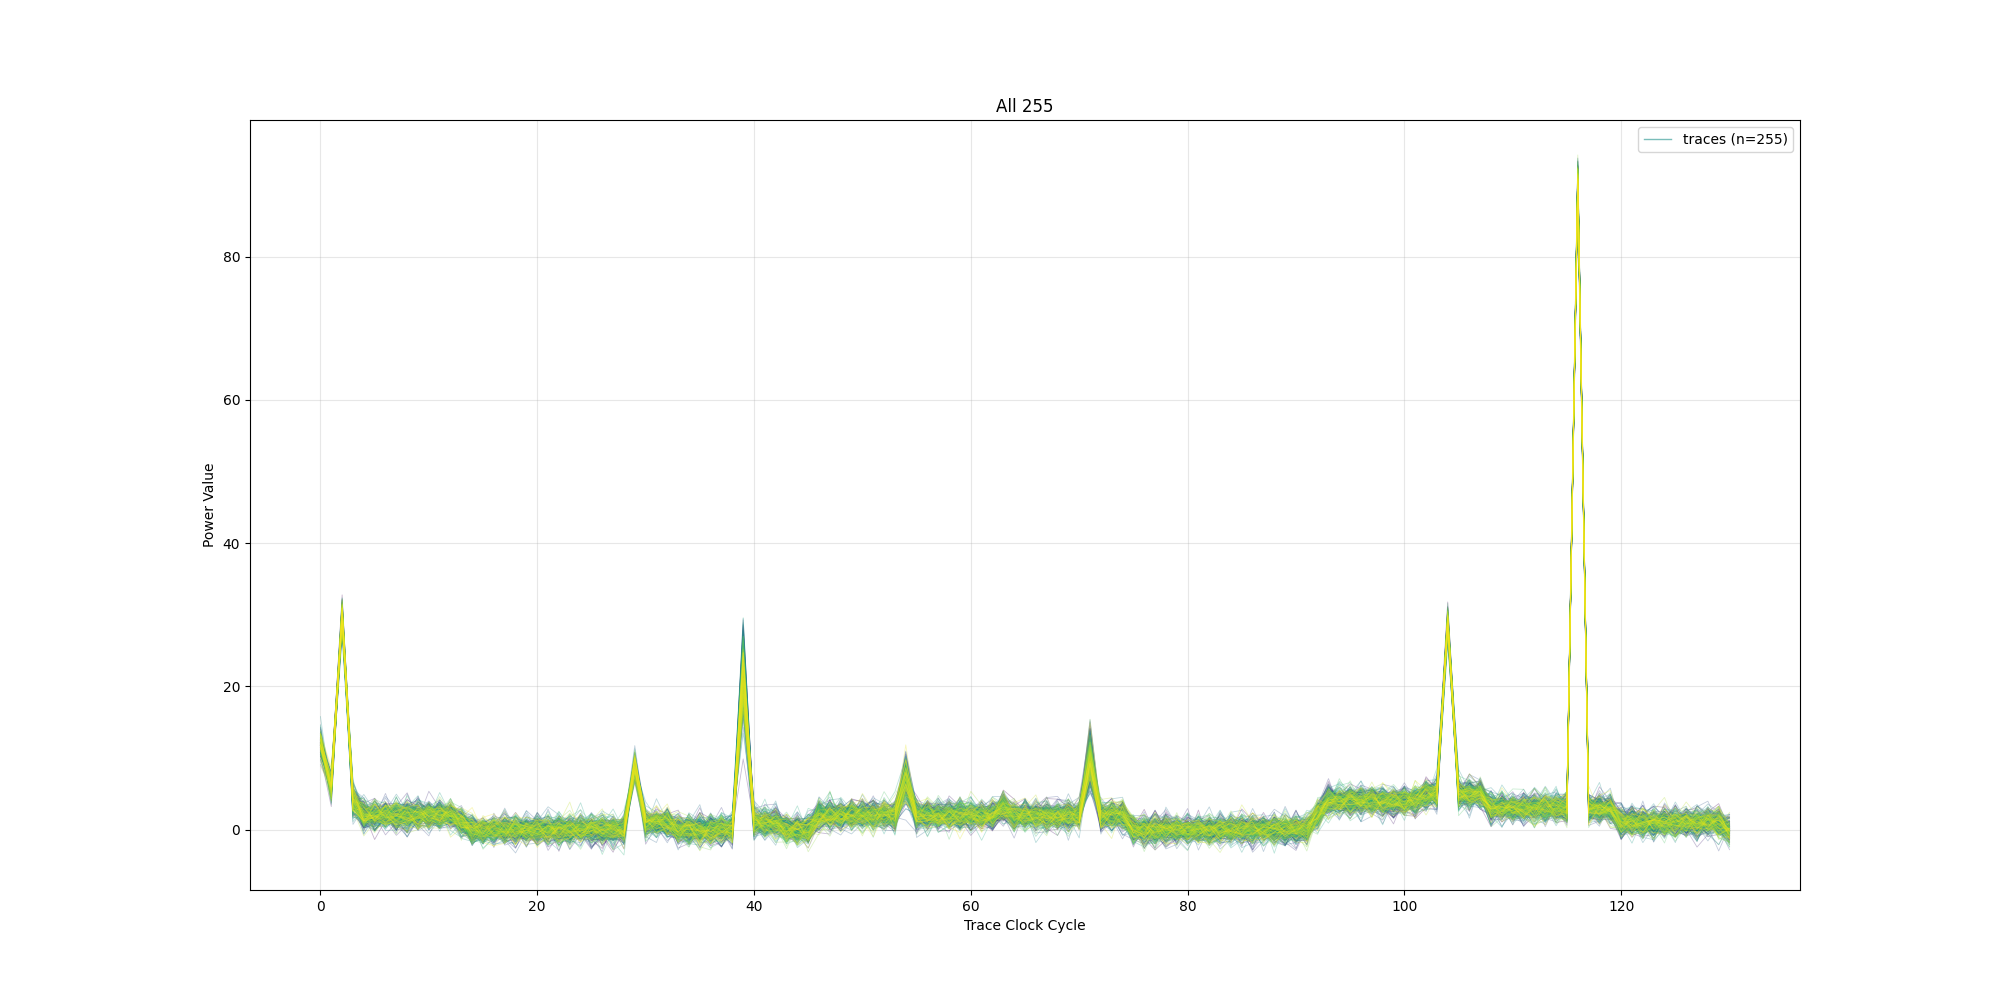

In [2]:
%matplotlib widget 
trace_data = np.load("traces/example-traces.npy")

min_len = min([len(n) for n in trace_data])
mean_trace = np.mean(trace_data, axis=0)

colors = cm.viridis(np.linspace(0, 1, len(trace_data)))
fig, ax = plt.subplots(figsize=(20, 10))

for i, data in enumerate(trace_data):
    ax.plot(data[:min_len], color = colors[i], alpha=0.3, linewidth=0.6)
ax.set_title(f"All {len(trace_data)}")
ax.set_ylabel("Power Value")

trace_proxy = Line2D([0], [0], color=cm.viridis(0.5), alpha=0.6, linewidth=1,
                     label=f"traces (n={len(trace_data)})")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[trace_proxy] + handles, labels=[trace_proxy.get_label()] + labels)
ax.set_xlabel("Trace Clock Cycle")
ax.grid(True, alpha=0.3)
plt.show()


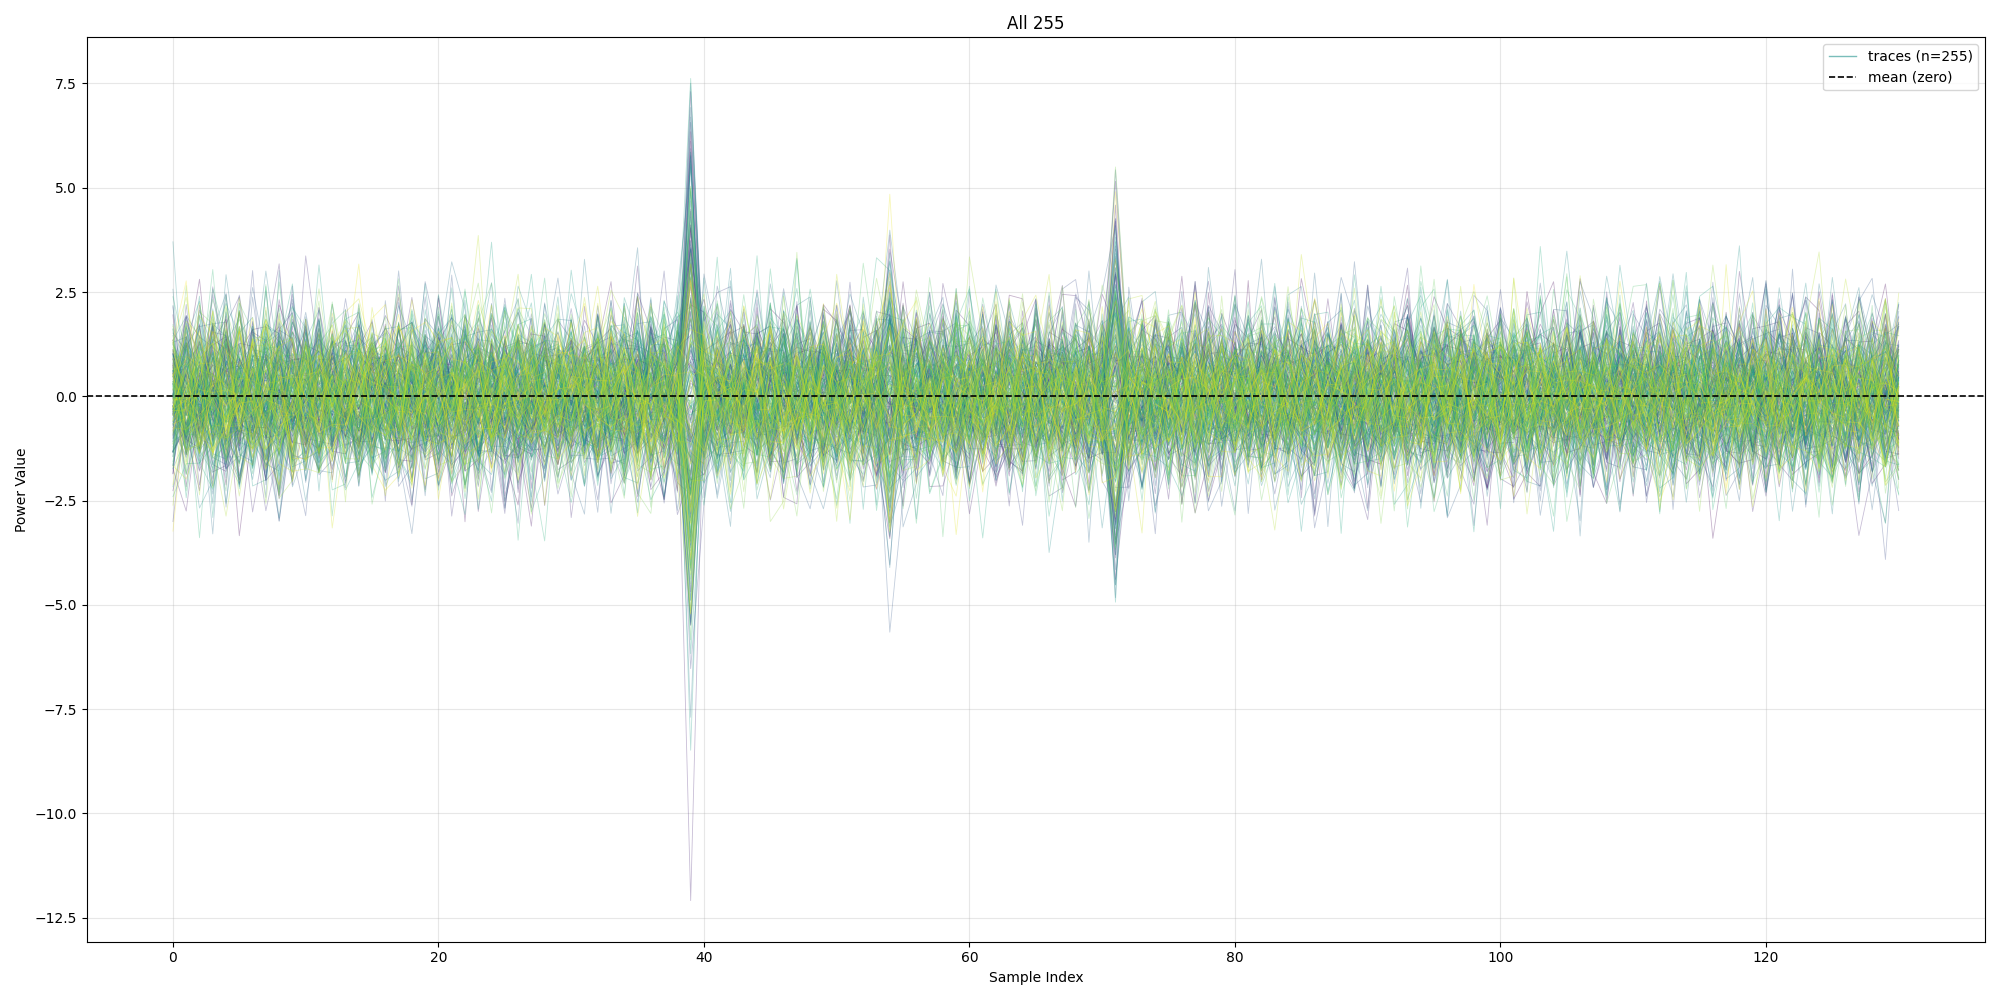

In [3]:
colors = cm.viridis(np.linspace(0, 1, len(trace_data)))
fig, ax = plt.subplots(figsize=(20, 10))

for i, data in enumerate(trace_data):
      ax.plot(data - mean_trace, color=colors[i], alpha=0.3, linewidth=0.6)
ax.axhline(0, color="black", linewidth=1.2, linestyle="--", label="mean (zero)")
ax.set_title(f"All {len(trace_data)} Power Traces — Difference from Mean")
ax.set_ylabel("Power Value − Mean")

ax.set_title(f"All {len(trace_data)}")
ax.set_ylabel("Power Value")

trace_proxy = Line2D([0], [0], color=cm.viridis(0.5), alpha=0.6, linewidth=1,
                     label=f"traces (n={len(trace_data)})")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[trace_proxy] + handles, labels=[trace_proxy.get_label()] + labels)
ax.set_xlabel("Sample Index")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Explanation

In the two graphs above we see trace recordings from our emulator. First and foremost we can notice that they are very similar, and only differ on 3 clock cycles (which can be observed best in the second graphic). These differences are dependen on the hamming weight differences of the sbox substition we described above. These are also the parts of the calculation we try to attack when using DPA or CPA. In both of these attacks we abuse the fact that in unsecured AES implementations the power draw when a lot of data is changed is significantly different and linearly dependent on that amount of bits changed. Since the SBox in AES is designed for confusion (changing a lot of data) we can abuse this fact with both of these attacks. 

## Hamming Weights

The graph below will show how different hamming weights of the input are directly observable from our power trace. For this we calculate the hamming weight for each input vector and group them together into groups of similar hamming weights. This then demonstrates that there are in our simple example big differences in the power draw between these groups which make our attacks possible. 


## Hamming Weight Grouping Analysis

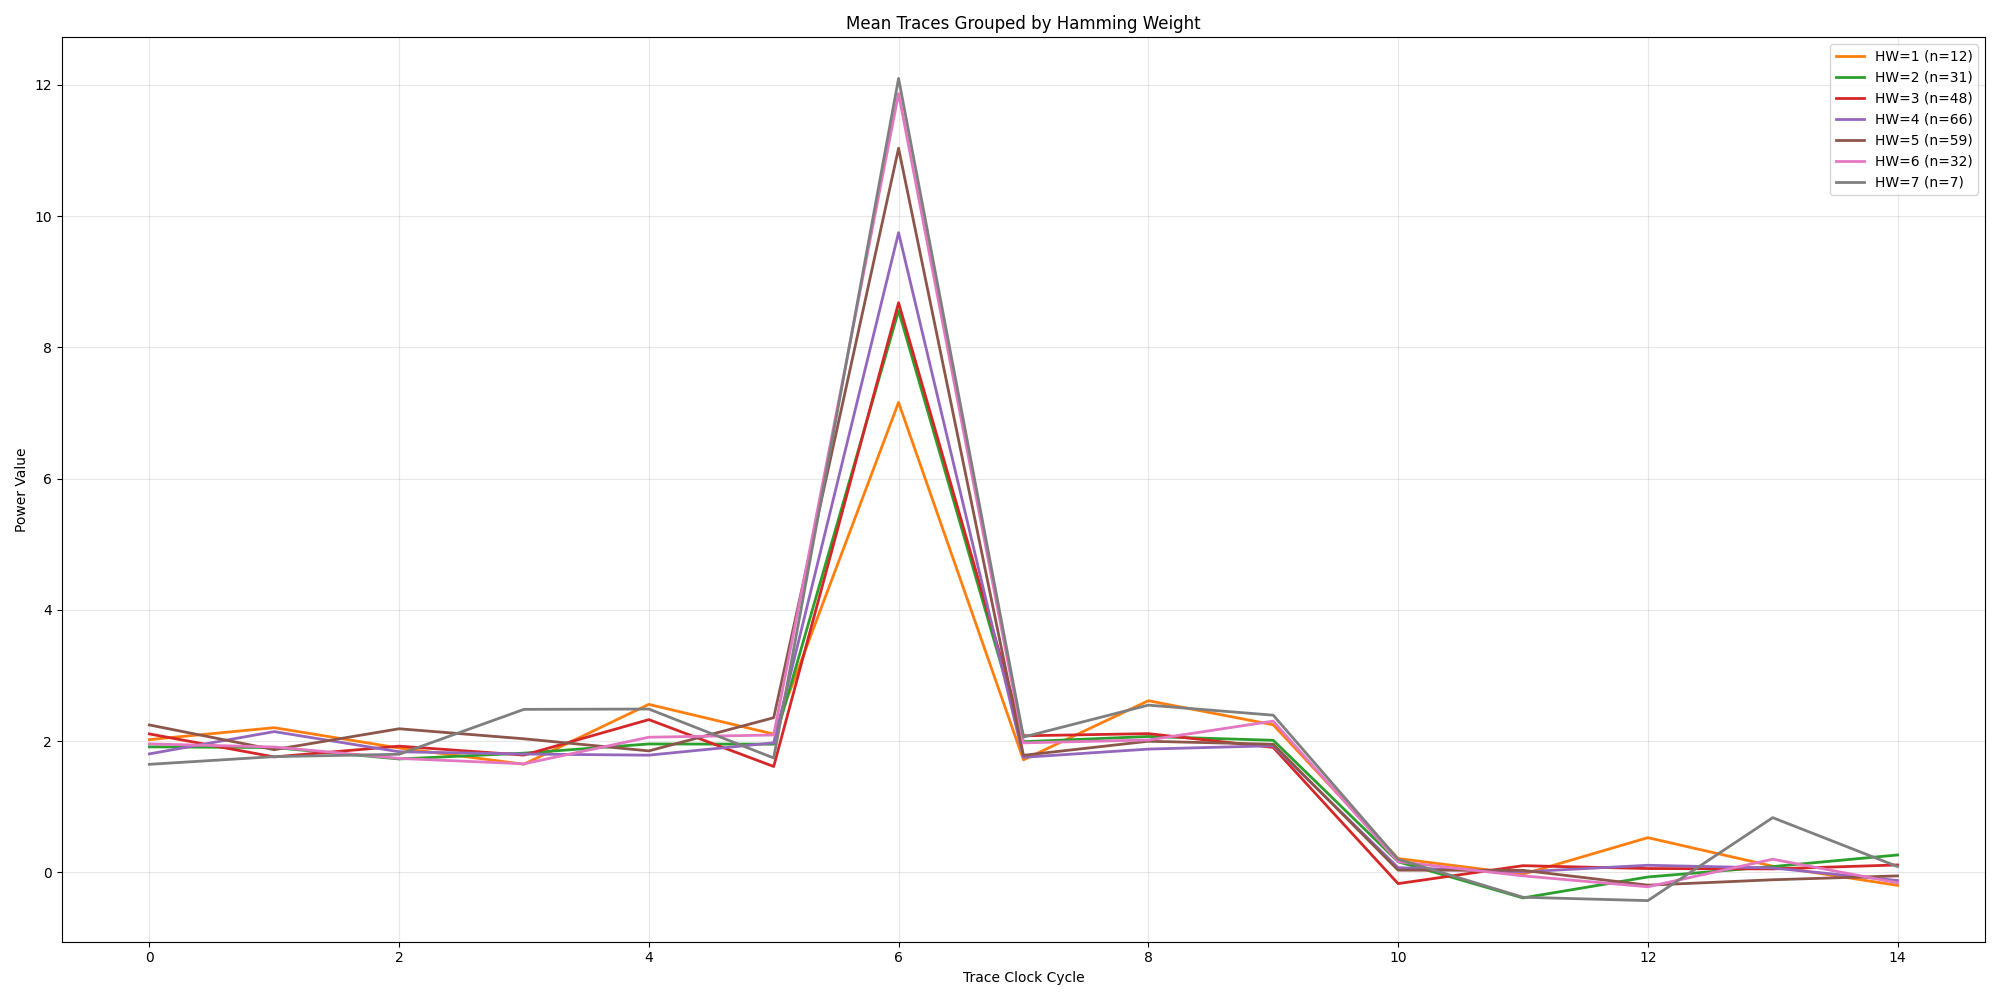

In [4]:
from src.power import SBOX

HW = [bin(n).count("1") for n in range(0, 256)]
hw_groups = {hw: [] for hw in range(9)} 

for trace_index in range(len(trace_data)):
    intermediate_value = trace_index ^ 0x1a ^ SBOX[trace_index ^ 0x1a] 
    hamming_weight = HW[intermediate_value]
    hw_groups[hamming_weight].append(trace_data[trace_index][65:80]) # Truncate the traces to zoom in on the actual part we attack.

hw_means = {}
for hw in range(9):
    if len(hw_groups[hw]) > 0:
        hw_means[hw] = np.mean(hw_groups[hw], axis=0)

colors = plt.cm.tab10(np.linspace(0, 0.9, 9))  
fig, ax = plt.subplots(figsize=(20, 10))

for hw in range(9):
    if hw in hw_means:
        ax.plot(hw_means[hw], color=colors[hw], linewidth=2.0, label=f"HW={hw} (n={len(hw_groups[hw])})")

ax.set_title("Mean Traces Grouped by Hamming Weight")
ax.set_ylabel("Power Value")
ax.set_xlabel("Trace Clock Cycle")
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Explanation

If we look closely into the graph we can observe the property that is used by DPA and CPA (as well as other attacks based on the same principle) to break AES. Namley the fact that bigger hamming weight swings result in higher power draw. Hamming weight groups 7 and 6 are at the top followed by 5, then 4, then a grouping of 3 and 2 and at last the lowest peak is at 1.

We can only observe these differences so clearly, because our power traces stem from an emulator that has no real physical properties. While you could also observe similar things from real power traces from real hardware, we should note that with a very controlled environment like our emulator we can get a much better view on the data. 

Also important to note is that the other 2 peaks we could observe above, seem to have no direct correlation with the actual SBox substitution as these peak show no measureable difference within our graph, as can be seen in the diagram below.

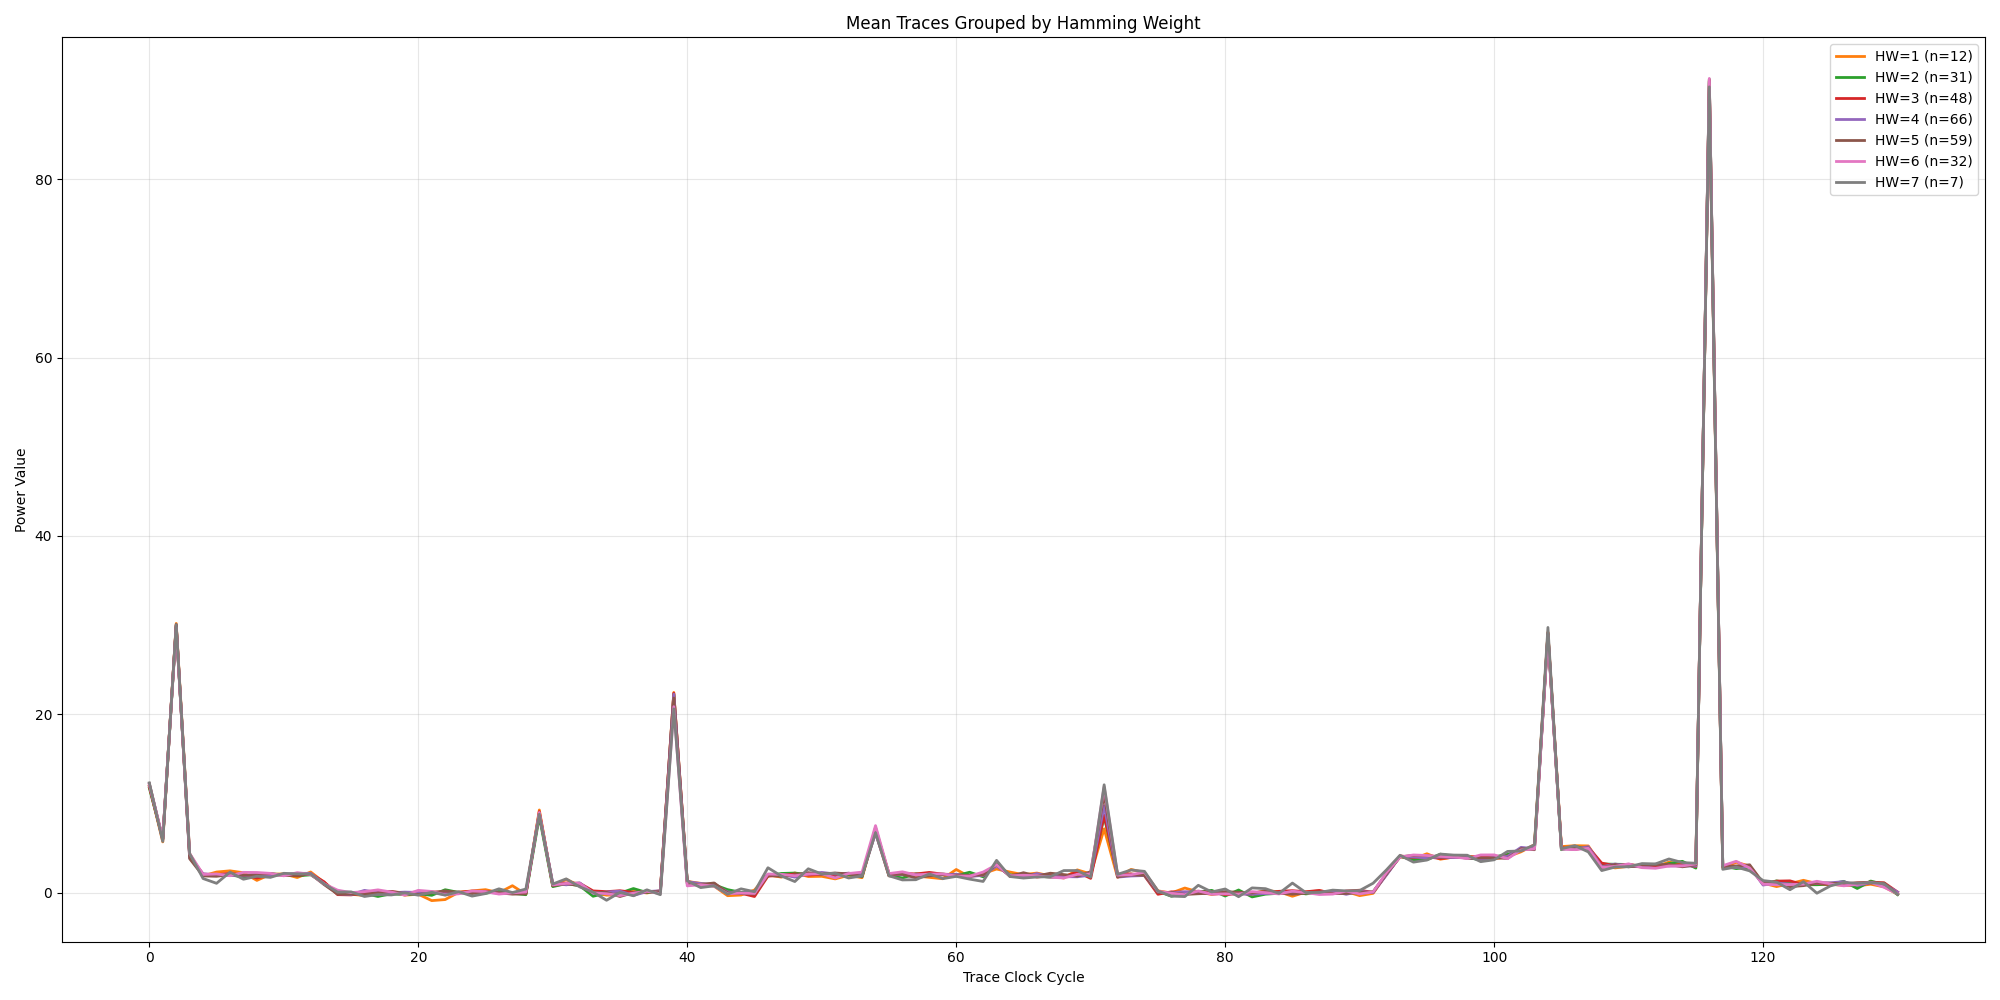

In [5]:
from src.power import SBOX

HW = [bin(n).count("1") for n in range(0, 256)]
hw_groups = {hw: [] for hw in range(9)} 

for trace_index in range(len(trace_data)):
    intermediate_value = trace_index ^ 0x1a ^ SBOX[trace_index ^ 0x1a] 
    hamming_weight = HW[intermediate_value]
    hw_groups[hamming_weight].append(trace_data[trace_index][:min_len]) # Truncate the traces to zoom in on the actual part we attack.

hw_means = {}
for hw in range(9):
    if len(hw_groups[hw]) > 0:
        hw_means[hw] = np.mean(hw_groups[hw], axis=0)

colors = plt.cm.tab10(np.linspace(0, 0.9, 9))  
fig, ax = plt.subplots(figsize=(20, 10))

for hw in range(9):
    if hw in hw_means:
        ax.plot(hw_means[hw], color=colors[hw], linewidth=2.0, label=f"HW={hw} (n={len(hw_groups[hw])})")

ax.set_title("Mean Traces Grouped by Hamming Weight")
ax.set_ylabel("Power Value")
ax.set_xlabel("Trace Clock Cycle")
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# DPA Attack

Now that we have seen the basis for our attacks, we are going to dive into the attacks itself. The power module of our emulator offers two classes which can perform DPA as well as CPA attacks by providing them with an array of tuples. The first part of each tuple in the array has to be the input_text bytes fed to the AES implementation we want to attack. The second part of the tuple has to be a numpy array, that contains a power trace produced by the teem emulator. Using this we can perform a simple DPA attack on the example data and recover the key. We have already provided most of the code below, you just need to load the data in the correct format to perform the attack. If you want a harder challenge you can also use the alternative data file. Just be aware that you will have to adjust the leakage model when creating the DPA class, because the leakage model of the alternative data is *different* to what we have assumed above!

In [6]:
from src.power import DPAAttack, SBOX

### Here you should add code to format the data correctly

input_data = []

for trace_index in range(len(trace_data)):
    input_data.append((trace_index, trace_data[trace_index]))

def leakage_model(input_byte, key_guess):
    return input_byte ^ key_guess ^ SBOX[input_byte ^ key_guess]

dpa = DPAAttack(input_data, leakage_model)

result = dpa.attack()

for r in range(len(result)):
    print(f"{r:02x} keyguess, guess estimate: {result[r]}")



00 keyguess, guess estimate: 0.5335054276132514
01 keyguess, guess estimate: 0.4507550972360299
02 keyguess, guess estimate: 0.4003477866831011
03 keyguess, guess estimate: 0.3967272126296906
04 keyguess, guess estimate: 0.477409518414035
05 keyguess, guess estimate: 0.37624554724250814
06 keyguess, guess estimate: 0.404868205636671
07 keyguess, guess estimate: 0.7235299320943369
08 keyguess, guess estimate: 0.33114024017060306
09 keyguess, guess estimate: 0.4245095610292715
0a keyguess, guess estimate: 0.3671900606561176
0b keyguess, guess estimate: 0.5563553506238108
0c keyguess, guess estimate: 1.4716974816953368
0d keyguess, guess estimate: 0.7496951350117413
0e keyguess, guess estimate: 0.4920584159248449
0f keyguess, guess estimate: 0.34042119730287457
10 keyguess, guess estimate: 0.4916418172192394
11 keyguess, guess estimate: 0.44594728157154506
12 keyguess, guess estimate: 0.3111546411132391
13 keyguess, guess estimate: 0.33876543439154627
14 keyguess, guess estimate: 0.354619

As we can see the DPA attack recovered 1a as the key which in our case is correct. Now we can also see that there are several other values that are quite near the value we have identified as our key. This can always happen especially if we work with real hardware so it is always important to keep this in mind. 

# CPA Attack 

Now that have used a DPA attack lets try to use a CPA attack to achieve similar results. The API of the CPA attack class in our power module is the same as in the DPA case, so you only have to change the class and should be able to get some results immediatly. 


In [7]:
from src.power import CPAAttack 


cpa = CPAAttack(input_data)

result = cpa.attack() 

for r in range(len(result)):
    print(f"{r:02x} keyguess, guess estimate: {result[r]}")

00 keyguess, guess estimate: 0.17658885606118366
01 keyguess, guess estimate: 0.14535421358884026
02 keyguess, guess estimate: 0.16836260229446814
03 keyguess, guess estimate: 0.16460064112775893
04 keyguess, guess estimate: 0.15391847941524975
05 keyguess, guess estimate: 0.16321266974365456
06 keyguess, guess estimate: 0.25716203090896944
07 keyguess, guess estimate: 0.18141540499917397
08 keyguess, guess estimate: 0.18211234196452936
09 keyguess, guess estimate: 0.1769593021215048
0a keyguess, guess estimate: 0.17466229375227976
0b keyguess, guess estimate: 0.19068274664222407
0c keyguess, guess estimate: 0.18388503460536712
0d keyguess, guess estimate: 0.18675551990834657
0e keyguess, guess estimate: 0.248266576203561
0f keyguess, guess estimate: 0.16470053413774152
10 keyguess, guess estimate: 0.1811582361533878
11 keyguess, guess estimate: 0.14788560070327098
12 keyguess, guess estimate: 0.2018709631229851
13 keyguess, guess estimate: 0.15194699029471298
14 keyguess, guess estima

Now essentially we can see that we got the same result, namely that 1a is the key byte, but in difference to the DPA example we can see that the result "seems" a lot more stable. 

# Counter Measures

While these examples in itself showed as what we are attacking and  wwhy it works, we will now introduce a simple counter measure against these types of attacks, namely random delay. For this please either modify the micro-aes implementation by using the trace_delay system call of the emulator. You should insert this system call immediatly before the SBox operation starts inside your trying window. Once you have done that please run the emulator and use our script to combine the results into one single file. 

If you are either too lazy or have issues when compiling the micro-aes implementation you can use the prebuilt program in the demo-power directory of this repository. 

## Tips

The execution of the emulator can take quite a while, especially if you just use c python to execute the programs. To speed up this process significantly we highly recommend the usage of pypy for the emulator. Using pypy can speed up the execution of the emulator up to 2x which will improve your experience when working with the emulator a great amount.

In [9]:
from src.cpu import CPU
from benedict import benedict

path = "./config.yml"
config = benedict.from_yaml(path)
cpu = CPU(config)

cpu.load_program_from_file("aes-delay-first-byte-varies.s")

while (info := cpu.tick()).executing_program:
    if cpu._console.has_output: 
        print(cpu._console.extract_output(True))


b'trace-0\x00'
b'trace-1\x00'
b'trace-2\x00'
b'trace-3\x00'
b'trace-4\x00'
b'trace-5\x00'
b'trace-6\x00'
b'trace-7\x00'
b'trace-8\x00'
b'trace-9\x00'
b'trace-10\x00'
b'trace-11\x00'
b'trace-12\x00'
b'trace-13\x00'
b'trace-14\x00'
b'trace-15\x00'
b'trace-16\x00'
b'trace-17\x00'
b'trace-18\x00'
b'trace-19\x00'
b'trace-20\x00'
b'trace-21\x00'
b'trace-22\x00'
b'trace-23\x00'
b'trace-24\x00'
b'trace-25\x00'
b'trace-26\x00'
b'trace-27\x00'
b'trace-28\x00'
b'trace-29\x00'
b'trace-30\x00'
b'trace-31\x00'
b'trace-32\x00'
b'trace-33\x00'
b'trace-34\x00'
b'trace-35\x00'
b'trace-36\x00'
b'trace-37\x00'
b'trace-38\x00'
b'trace-39\x00'
b'trace-40\x00'
b'trace-41\x00'
b'trace-42\x00'
b'trace-43\x00'
b'trace-44\x00'
b'trace-45\x00'
b'trace-46\x00'
b'trace-47\x00'
b'trace-48\x00'
b'trace-49\x00'
b'trace-50\x00'
b'trace-51\x00'
b'trace-52\x00'
b'trace-53\x00'
b'trace-54\x00'
b'trace-55\x00'
b'trace-56\x00'
b'trace-57\x00'
b'trace-58\x00'
b'trace-59\x00'
b'trace-60\x00'
b'trace-61\x00'
b'trace-62\x00'
b'

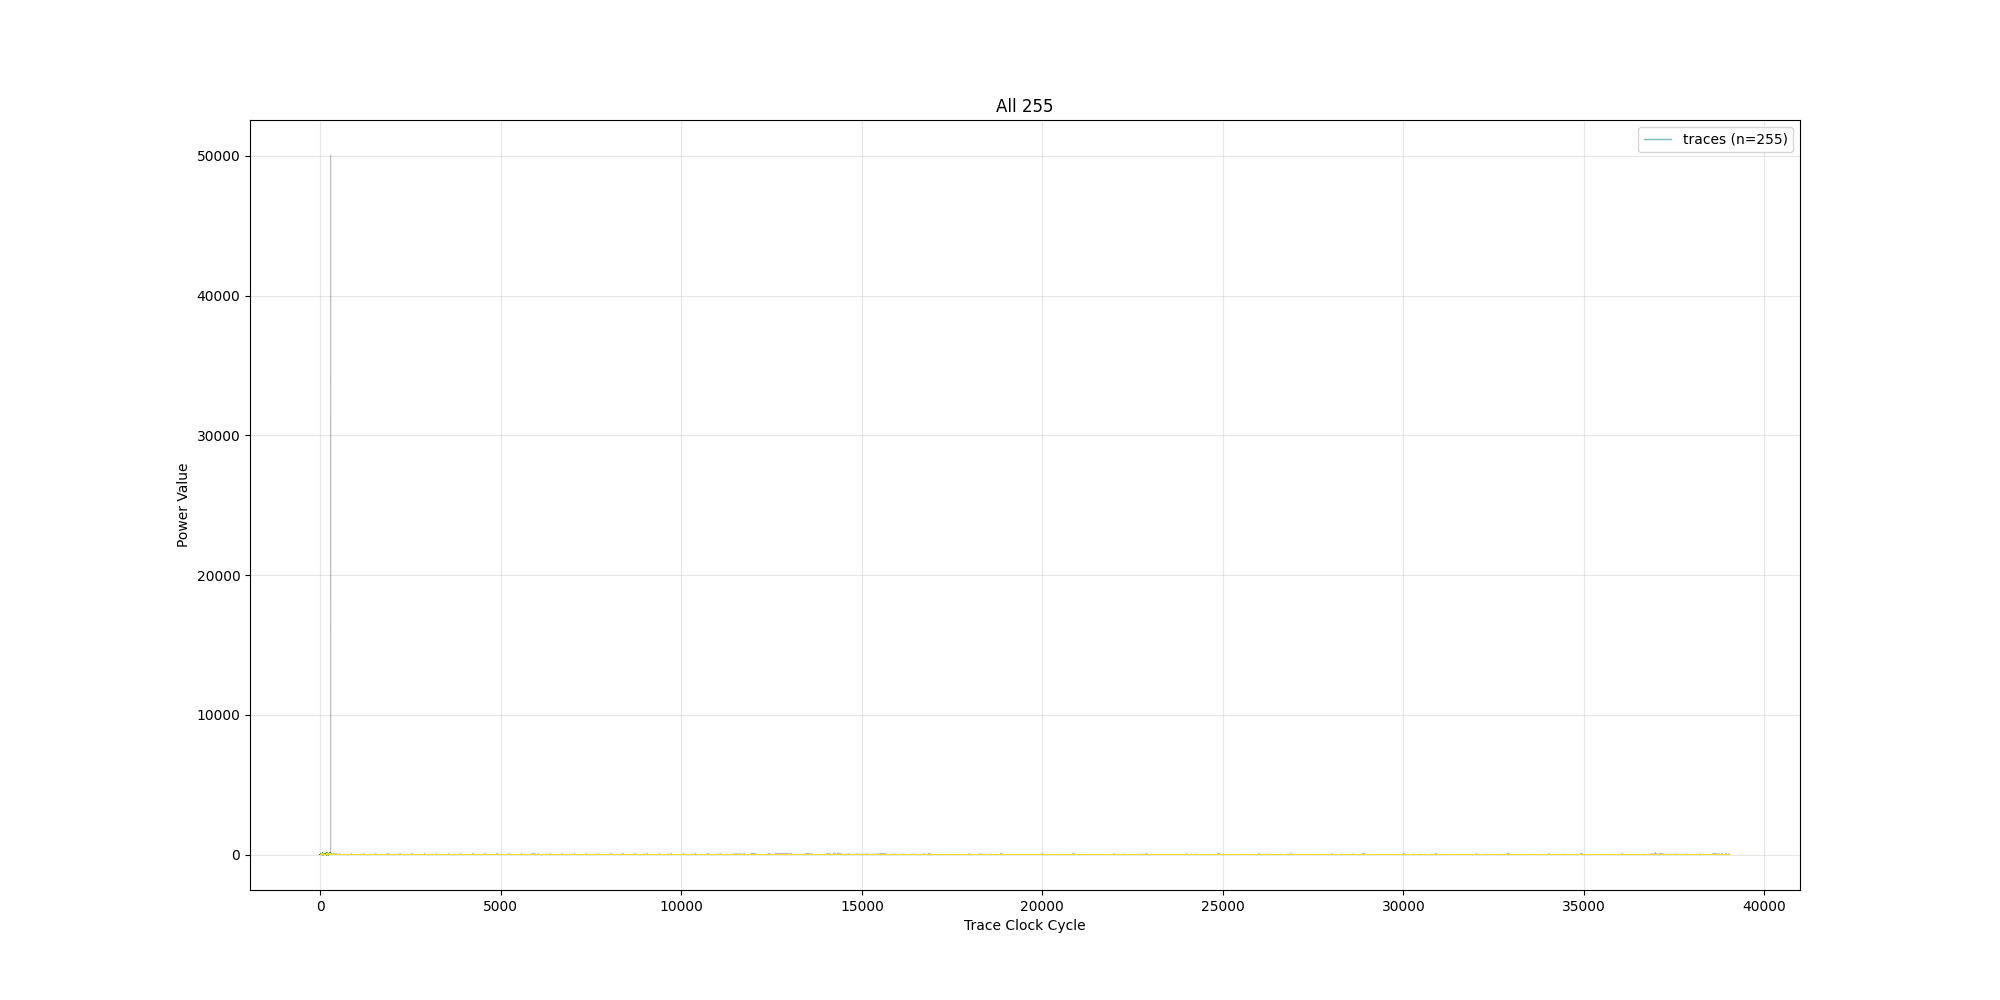

In [10]:
%matplotlib widget 
trace_data = np.load("traces/delay-example-traces.npy")

min_len = min([len(n) for n in trace_data])
mean_trace = np.mean(trace_data, axis=0)

colors = cm.viridis(np.linspace(0, 1, len(trace_data)))
fig, ax = plt.subplots(figsize=(20, 10))

for i, data in enumerate(trace_data):
    ax.plot(data[:min_len], color = colors[i], alpha=0.3, linewidth=0.6)
ax.set_title(f"All {len(trace_data)}")
ax.set_ylabel("Power Value")

trace_proxy = Line2D([0], [0], color=cm.viridis(0.5), alpha=0.6, linewidth=1,
                     label=f"traces (n={len(trace_data)})")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[trace_proxy] + handles, labels=[trace_proxy.get_label()] + labels)
ax.set_xlabel("Trace Clock Cycle")
ax.grid(True, alpha=0.3)
plt.show()